In [ ]:
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from behavior.running import get_rest_array
from utilities.traces import  mean_rates
from utilities.animal import animal
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import ast
import pingouin as pg
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')


In [2]:
from scipy import stats as scipy_stats

def lmm_contrast(model, coef_names):
    """Test sum of named coefficients = 0."""
    params = model.params
    cov    = model.cov_params()
    c = np.zeros(len(params))
    for name in coef_names:
        c[params.index.get_loc(name)] = 1.0
    est = c @ params.values
    se  = np.sqrt(c @ cov.values @ c)
    z   = est / se
    p   = 2 * scipy_stats.norm.sf(abs(z))
    print(f"Estimate: {est:.3f}  SE: {se:.3f}  z: {z:.3f}  p: {p:.4f}")
    return est, se, z, p

In [3]:
data_dir='/Users/amonast/Desktop/Tone2P'
file_key='/Users/amonast/Desktop/Tone2P/Data_info_TFC.csv'
sessions=['Recall2']
animals = ['F5L','F7N','M8BL2','M9BR2','939L',]
colors = ['#00ABC8','#F37243'] #Non-engram, Engram
palette={False:colors[0],True:colors[1]}
gray='#424949' 


## TRACE

In [4]:
def mask_to_intervals(timestamps, bool_mask):
    """Convert a boolean mask over timestamps into a list of (t0, t1) tuples."""
    s = pd.Series(bool_mask.astype(int), index=timestamps)
    if s.sum() == 0:
        return []
    groups = (s != s.shift()).cumsum()
    return [(g.index.min(), g.index.max()) for _, g in s[s == 1].groupby(groups)]

fov = 'FOV1'
session = 'Recall2'
df_state_tot = []
animals = ['F5L','F7N','M8BL2','M9BR2','939L',]

for ani in animals:
    mouse = animal(ani, fov, file_key, data_dir)
    traces_df = mouse.load_traces(sessions=[session], split=False, signal='events', zscore=False)
    on_times1, off_times1, on_times2, off_times2 = mouse.load_tone_times(session_name=session)

    intervals1 = list(zip(off_times1[:], off_times1[:]+20))
    intervals2 = list(zip(off_times2[:], off_times2[:]+20))

    timestamps = traces_df['timestamps'].to_numpy()
    velocity = np.load(f"{data_dir}/Traces/{ani}_{fov}_{session}_velocity0.5s.npy", allow_pickle=True)
    rest_array, run_array = get_rest_array(velocity, bout=0.5)

    for cs_label, intervals in [('cs1', intervals1), ('cs2', intervals2)]:
        for trial, (t0, t1) in enumerate(intervals):
            trial_mask = (timestamps >= t0) & (timestamps <= t1)

            for state_label, state_arr in [('rest', rest_array), ('run', run_array)]:
                state_mask = trial_mask & state_arr.astype(bool)
                if state_mask.sum() == 0:
                    continue

                state_intervals = mask_to_intervals(timestamps, state_mask)
                r = mean_rates(traces_df, session_name=session,
                               time_ranges=state_intervals, weighted=True)
                r['cs']            = cs_label
                r['animal']        = ani
                r['trial']         = trial
                r['state']         = state_label
                r['mean_velocity'] = np.nanmean(velocity[state_mask])
                df_state_tot.append(r)

df_state = pd.concat(df_state_tot).reset_index(drop=True)
df_state = df_state[df_state['mean_rate'] != 0].reset_index(drop=True)
df_state['log_rate'] = np.log(df_state['mean_rate'])

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
# One row per cell per CS per state (trials averaged) — handles cell identity
cell_state_df = df_state.groupby(['animal','cell','is_engram','cs','state']).agg(
    mean_rate=('mean_rate','mean'),
    mean_velocity=('mean_velocity','mean')).reset_index().dropna().reset_index(drop=True)
cell_state_df['log_rate'] = np.log(cell_state_df['mean_rate'])
cell_state_df['is_engram'] = pd.Categorical(cell_state_df['is_engram'], categories=[False, True])
cell_state_df['id'] = cell_state_df['animal']+'_'+cell_state_df['cell']

### Model no Running

In [6]:
model_1= smf.mixedlm("log_rate ~ is_engram * cs ",
                           data=cell_state_df, groups='animal',).fit(reml=False)
model_1.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
=======================================================================
Model:                 MixedLM      Dependent Variable:      log_rate  
No. Observations:      2169         Method:                  ML        
No. Groups:            5            Scale:                   1.3287    
Min. group size:       300          Log-Likelihood:          -3388.9735
Max. group size:       543          Converged:               Yes       
Mean group size:       433.8                                           
-----------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                   -1.317    0.061 -21.418 0.000 -1.437 -1.196
is_engram[T.True]            0.107    0.071   1.510 0.131 -0.032  0.246
cs[T.cs2]                    0.019    0.066   0.286 0.775 -0.111  0.149
is_engram[T.True]:cs[T.cs2] -0.026    0.100  -0.256 0.798 -0.221  0.170
animal Var                   0.008    0.006                            
=======================================================================

"""

### Model with run state

In [7]:

# 3-way LMM: does engram x CS selectivity depend on locomotion state?
# is_engram:cs:state is the key term
model_state = smf.mixedlm("log_rate ~ is_engram * cs * state",
                           data=cell_state_df, groups='animal',).fit(reml=False)
model_state.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
====================================================================================
Model:                      MixedLM          Dependent Variable:          log_rate  
No. Observations:           2169             Method:                      ML        
No. Groups:                 5                Scale:                       1.0938    
Min. group size:            300              Log-Likelihood:              -3178.8933
Max. group size:            543              Converged:                   Yes       
Mean group size:            433.8                                                   
------------------------------------------------------------------------------------
                                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                -1.703    0.072 -23.747 0.000 -1.844 -1.563
is_engram[T.True]                        -0.013    0.085  -0.159 0.874 -0.179  0.152
cs[T.cs2]                                -0.003    0.079  -0.033 0.973 -0.158  0.153
state[T.run]                              0.918    0.086  10.700 0.000  0.750  1.086
is_engram[T.True]:cs[T.cs2]               0.150    0.120   1.254 0.210 -0.085  0.385
is_engram[T.True]:state[T.run]            0.313    0.129   2.419 0.016  0.059  0.566
cs[T.cs2]:state[T.run]                    0.043    0.122   0.349 0.727 -0.196  0.281
is_engram[T.True]:cs[T.cs2]:state[T.run] -0.447    0.183  -2.442 0.015 -0.805 -0.088
animal Var                                0.010    0.008                            
====================================================================================

"""

#### Post hoc contrasts from lmm

In [8]:

print(model_state.params.index.tolist())

['Intercept', 'is_engram[T.True]', 'cs[T.cs2]', 'state[T.run]', 'is_engram[T.True]:cs[T.cs2]', 'is_engram[T.True]:state[T.run]', 'cs[T.cs2]:state[T.run]', 'is_engram[T.True]:cs[T.cs2]:state[T.run]', 'animal Var']


In [9]:
print('Engram vs non-engram during CS+ (cs1) rest')#  — cs1 is reference, no cs term')
lmm_contrast(model_state, [
    'is_engram[T.True]'])

print('Engram vs non-engram during CS+ (cs1) run')
lmm_contrast(model_state, [
    'is_engram[T.True]',
    'is_engram[T.True]:state[T.run]'])

print('Engram vs non-engram during CS- (cs2) rest')
lmm_contrast(model_state, [
    'is_engram[T.True]',
    'is_engram[T.True]:cs[T.cs2]'])

print('Engram vs non-engram during CS- (cs2) run')
lmm_contrast(model_state, [
    'is_engram[T.True]',
    'is_engram[T.True]:cs[T.cs2]',
    'is_engram[T.True]:state[T.run]',
    'is_engram[T.True]:cs[T.cs2]:state[T.run]'])


Engram vs non-engram during CS+ (cs1) rest
Estimate: -0.013  SE: 0.085  z: -0.159  p: 0.8740
Engram vs non-engram during CS+ (cs1) run
Estimate: 0.299  SE: 0.099  z: 3.036  p: 0.0024
Engram vs non-engram during CS- (cs2) rest
Estimate: 0.137  SE: 0.085  z: 1.601  p: 0.1094
Engram vs non-engram during CS- (cs2) run
Estimate: 0.003  SE: 0.098  z: 0.030  p: 0.9762


(0.0029187034985047045,
 0.09776418753500304,
 0.029854526203265435,
 0.9761830725006149)

In [10]:
# Likelihood ratio test
lr_stat = 2 * (model_state.llf - model_1.llf)
df_diff = len(model_state.fe_params) - len(model_1.fe_params)
p_lrt   = stats.chi2.sf(lr_stat, df=df_diff)

print(f"LR statistic : {lr_stat:.3f}")
print(f"df difference: {df_diff}")
print(f"p-value      : {p_lrt}")


LR statistic : 420.160
df difference: 4
p-value      : 1.224019510104104e-89


Text(0.5, 1.0, 'CS- Trace')

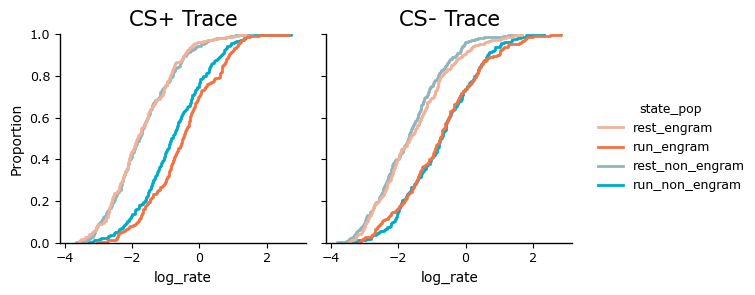

In [17]:
ecdf_data  = cell_state_df.copy()
ecdf_data['state_pop'] = ecdf_data['state']+'_'+   ecdf_data['is_engram'].astype(str).map({'True': 'engram', 'False': 'non_engram'})

state_palette = {'run_non_engram':'#00ABC8',
                 'run_engram':'#F37243',
                 'rest_non_engram':"#8FB5BC",
                 'rest_engram':"#EFB29B"}
g=sb.displot(kind='ecdf',data=ecdf_data
             ,x='log_rate',hue='state_pop',
             height=3,aspect=1,
             palette=state_palette,col='cs')
g.axes[0][0].set_title('CS+ Trace')
g.axes[0][1].set_title('CS- Trace')
#plt.savefig('SuppFig8B.svg',transparent=True)

# Supp Figure 8E

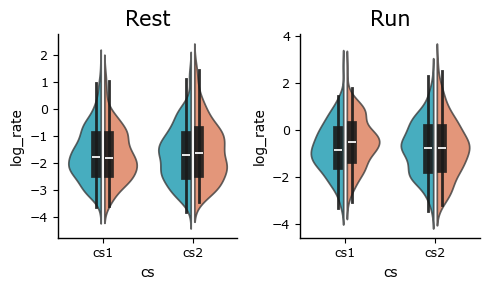

In [16]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(5,3), sharey=False)

for axis, state, title in zip(ax, ['rest', 'run'], ['Rest', 'Run']):
    sb.violinplot(data=cell_state_df.loc[cell_state_df['state'] == state],
                  y='log_rate', x='cs', hue='is_engram',
                  dodge=.5, width=.8, gap=0.1,
                  density_norm='width', split=True,
                  alpha=0.8, inner='box',
                  palette=colors,
                  inner_kws=dict(box_width=7, whis_width=2, color="0.1", alpha=0.9),
                  ax=axis)
    axis.set_title(title)
    axis.legend_.remove()

sb.despine()
plt.tight_layout()
plt.savefig('SuppFig8E_violinplot_trace.svg', transparent=True)


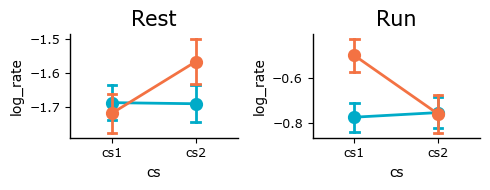

In [15]:
fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(5,2),sharey=False)
sb.pointplot(data=cell_state_df.loc[(cell_state_df['state']=='rest')],y='log_rate',hue='is_engram',x='cs',ax=ax[0],
            errorbar='se',palette=colors,
            capsize=.1,markersize=8,linewidth=2)
ax[0].set_title('Rest')
sb.pointplot(data=cell_state_df.loc[(cell_state_df['state']=='run')],y='log_rate',hue='is_engram',x='cs',ax=ax[1],
             errorbar='se',palette=colors,
             capsize=.1,markersize=8,linewidth=2)
ax[1].set_title('Run')
ax[0].legend_.remove()
ax[1].legend_.remove()
plt.tight_layout()
sb.despine()
plt.savefig('SuppFig8E_pointplot_trace.svg',transparent=True)

# Velocity - Supp Fig 8F-G

In [56]:
# Mean velocity over the full trace window per trial per CS (no state split)
vel_tot = []
for ani in animals:
    mouse = animal(ani, fov, file_key, data_dir)
    traces_df = mouse.load_traces(sessions=[session], split=False, signal='events', zscore=False)
    on_times1, off_times1, on_times2, off_times2 = mouse.load_tone_times(session_name=session)
    timestamps = traces_df['timestamps'].to_numpy()
    velocity = np.load(f"{data_dir}/Traces/{ani}_{fov}_{session}_velocity0.5s.npy", allow_pickle=True)

    for cs_label, on_t, off_t in [('cs1', on_times1, off_times1),
                                   ('cs2', on_times2, off_times2)]:
        for trial, (t0, t1) in enumerate(zip(off_t, off_t + 20)):
            mask = (timestamps >= t0) & (timestamps <= t1)
            vel_tot.append({'animal': ani, 'cs': cs_label,
                            'trial': trial,
                            'mean_velocity': np.nanmean(velocity[mask])})

vel_df = pd.DataFrame(vel_tot)

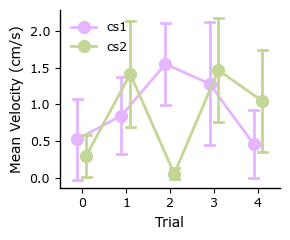

In [58]:
colors_cs = {'cs1':'#E5B5FF','cs2':'#C3D696'}

fig, ax = plt.subplots(figsize=(3,2.5))
sb.pointplot(data=vel_df, x='trial', y='mean_velocity', hue='cs',
             palette=colors_cs, 
             markersize=8,
             dodge=0.2, errorbar='se', capsize=0.2,
             linewidth=2, ax=ax)
ax.set_xlabel('Trial')
ax.set_ylabel('Mean Velocity (cm/s)')
sb.despine()
plt.tight_layout()
plt.legend(frameon=False)
plt.savefig('SuppFig8_velocity_trace_pointplot.svg',transparent=True)

In [59]:
pg.rm_anova(data=vel_df,dv='mean_velocity',within=['trial','cs'],subject='animal')

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,trial,5.451313,4,16,1.362828,0.884416,0.495322,0.446049,0.074436,0.473536
1,cs,0.074369,1,4,0.074369,0.032971,0.864743,0.864743,0.001096,1.000000
2,trial * cs,7.389836,4,16,1.847459,1.273197,0.321358,0.330836,0.098304,0.558201


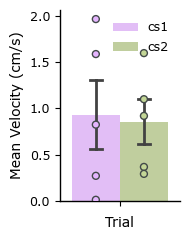

In [60]:
colors_cs = {'cs1':'#E5B5FF','cs2':'#C3D696'}

fig, ax = plt.subplots(figsize=(2,2.5))
sb.barplot(data=vel_df.groupby(['animal','cs']).mean(numeric_only=True).reset_index(), 
             y='mean_velocity', 
             hue='cs',
             palette=colors_cs, 
             dodge=0.2, errorbar='se', capsize=0.2,err_kws={'linewidth':2}, ax=ax)
sb.stripplot(data=vel_df.groupby(['animal','cs']).mean(numeric_only=True).reset_index(), 
            y='mean_velocity', 
             hue='cs',
             palette=colors_cs, legend=False,
             dodge=0.2, jitter=False,edgecolor=gray,linewidth=1, ax=ax)
ax.set_xlabel('Trial')
ax.set_ylabel('Mean Velocity (cm/s)',size=10)
sb.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('SuppFig8_velocity_trace_barplot.svg',transparent=True)

In [44]:
pg.pairwise_tests(data=vel_df.groupby(['animal','cs']).mean(numeric_only=True).reset_index(),
                 dv='mean_velocity',within='cs',subject='animal')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,cs,cs1,cs2,True,True,0.181579,4.0,two-sided,0.864743,0.403,0.098744


# Baseline - Recall2

In [17]:
def extract_activity(df, start_t, stop_t, binarize=False):
    mask = (df['timestamps'] >= start_t) & (df['timestamps'] <= stop_t)
    X = df.loc[mask, :]

    inds = np.flatnonzero(mask.to_numpy())  # positional row indices

    if binarize:
        X = X.copy()
        X[X > 0] = 1

    return X, inds

In [18]:
# Baseline (0-540s): per-cell rates by locomotion state, with animal tagged
# Comparison model — tests whether engram:run effect exists before any CS presentation
baseline_state_tot = []

for ani in animals:
    mouse = animal(ani, 'FOV1', file_key, data_dir)
    traces_df = mouse.load_traces(sessions=['Recall2'], split=False, signal='events', zscore=False)
    baseline_act, ti = extract_activity(traces_df, 0, 540)
    timestamps_bl = baseline_act['timestamps'].to_numpy()

    velocity = np.load(f"{data_dir}/Traces/{ani}_FOV1_Recall2_velocity0.5s.npy", allow_pickle=True)
    rest_array, run_array = get_rest_array(velocity, bout=0.5)

    for state_label, state_arr in [('rest', rest_array[ti]), ('run', run_array[ti])]:
        state_mask = state_arr.astype(bool)
        if state_mask.sum() == 0:
            continue
        state_intervals = mask_to_intervals(timestamps_bl, state_mask)
        r = mean_rates(baseline_act, session_name='Recall2',
                       time_ranges=state_intervals, weighted=True)
        r['animal'] = ani
        r['state']  = state_label
        baseline_state_tot.append(r)

df_baseline_state = pd.concat(baseline_state_tot).reset_index(drop=True)
df_baseline_state = df_baseline_state[df_baseline_state['mean_rate'] != 0].reset_index(drop=True)
df_baseline_state['log_rate']  = np.log(df_baseline_state['mean_rate'])
df_baseline_state['is_engram'] = pd.Categorical(df_baseline_state['is_engram'], categories=[False, True])
df_baseline_state['id'] = df_baseline_state['animal']+'_'+df_baseline_state['cell']
model_baseline_state = smf.mixedlm("log_rate ~ is_engram * state",
                                    data=df_baseline_state, groups='animal',
                                    vc_formula={'cell_id': '0 + C(id)'}).fit()
model_baseline_state.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
==========================================================================
Model:                  MixedLM       Dependent Variable:       log_rate  
No. Observations:       1486          Method:                   REML      
No. Groups:             5             Scale:                    1.7419    
Min. group size:        251           Log-Likelihood:           -2613.4026
Max. group size:        358           Converged:                Yes       
Mean group size:        297.2                                             
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      -3.064    0.065 -47.401 0.000 -3.190 -2.937
is_engram[T.True]               0.210    0.099   2.128 0.033  0.017  0.404
state[T.run]                    1.294    0.092  14.126 0.000  1.115  1.474
is_engram[T.True]:state[T.run] -0.006    0.140  -0.044 0.965 -0.281  0.269
cell_id Var                     0.230    0.063                            
==========================================================================

"""

In [19]:
model_baseline_state.pvalues

Intercept                         0.000000e+00
is_engram[T.True]                 3.329765e-02
state[T.run]                      2.637695e-45
is_engram[T.True]:state[T.run]    9.652769e-01
cell_id Var                       6.012183e-03
dtype: float64

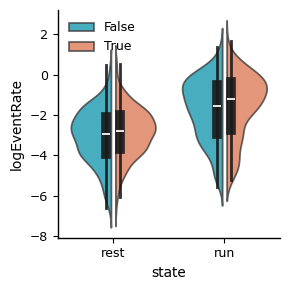

In [20]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3,3), sharey=False)

sb.violinplot(data=df_baseline_state,
                y='log_rate', x='state',hue='is_engram',
                dodge=.5, width=.8, gap=0.1,
                density_norm='width', split=True,
                alpha=0.8, inner='box',
                palette=colors,
                inner_kws=dict(box_width=7, whis_width=2, color="0.1", alpha=0.9),
                ax=ax)
axis.set_title(title)
plt.ylabel('logEventRate')
plt.legend(frameon=False)
sb.despine()
plt.tight_layout()
plt.savefig('SuppFig8B_baseline_violinplot.svg', transparent=True)


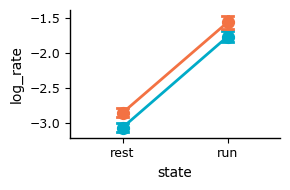

In [21]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(3, 2), sharey=True)

sb.pointplot(data=df_baseline_state,
             y='log_rate', hue='is_engram',x='state',
             ax=ax, errorbar='se', palette=colors,
             capsize=.1, markersize=8, linewidth=2, legend=False)
# ax[0].set_title('Run')
# sb.pointplot(data=df_baseline_state.loc[df_baseline_state['state'] == 'rest'],
#              y='log_rate', hue='is_engram',
#              ax=ax[1], errorbar='se', palette=colors,
#              capsize=.1, markersize=8, linewidth=2, legend=False)
# ax[1].set_title('Rest')
plt.tight_layout()
sb.despine()
plt.savefig('SuppFig8B_baseline_pointplot.svg', transparent=True)


In [22]:
baseline_ecdf_data = df_baseline_state.copy()
baseline_ecdf_data['state_pop'] = baseline_ecdf_data['state']+'_'+   baseline_ecdf_data['is_engram'].astype(str).map({'True': 'engram', 'False': 'non_engram'})

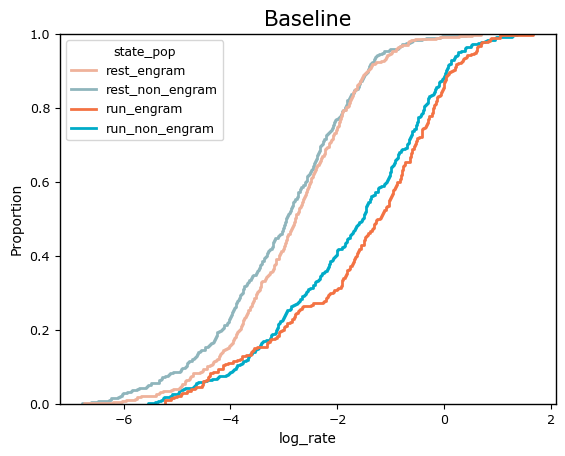

In [ ]:
g=sb.ecdfplot(data=baseline_ecdf_data
             ,x='log_rate',hue='state_pop',
             palette=state_palette)
plt.title('Baseline')
#plt.savefig('SuppFig8B.svg',transparent=True)

In [24]:
print('Engram vs non-engram during CS+ (cs1) rest')#  — cs1 is reference, no cs term')
lmm_contrast(model_baseline_state, [
    'is_engram[T.True]'])

print('Engram vs non-engram during CS+ (cs1) run')
lmm_contrast(model_baseline_state, [
    'is_engram[T.True]',
    'is_engram[T.True]:state[T.run]'])

Engram vs non-engram during CS+ (cs1) rest
Estimate: 0.210  SE: 0.099  z: 2.128  p: 0.0333
Engram vs non-engram during CS+ (cs1) run
Estimate: 0.204  SE: 0.110  z: 1.847  p: 0.0647


(0.20403356491171454,
 0.11044234286514494,
 1.8474215560679357,
 0.06468606742610858)

# Recall1 - Baseline / Rest 

## Supp Fig 8B

In [25]:
colors = ['#00ABC8','#F37243'] #Non-engram, Engram
palette={False:colors[0],True:colors[1]}

In [26]:
df = pd.read_csv("/Users/amonast/Desktop/Tone2P/Analysis/rates/baseline_tones_split_updated.csv",index_col=0)

In [27]:
df_baseline = df.loc[df['epoch']=='baseline']
df_baseline.head()

,cell,mean_rate,is_engram,session,animal,epoch,animal_cell
0,E_45,0.016609,True,Recall1,997B,baseline,997B_E_45
1,E_313,0.032548,True,Recall1,997B,baseline,997B_E_313
2,E_93,0.054555,True,Recall1,997B,baseline,997B_E_93
3,E_276,0.106072,True,Recall1,997B,baseline,997B_E_276
4,E_131,0.032773,True,Recall1,997B,baseline,997B_E_131


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_59722/1884085666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_baseline['log_rate']=np.log(df_baseline['mean_rate'])


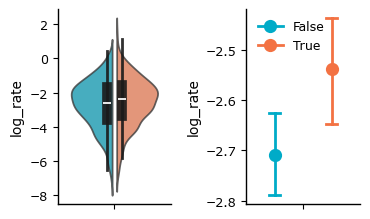

In [28]:
df_baseline['log_rate']=np.log(df_baseline['mean_rate'])
df_baseline=df_baseline[np.isfinite(df_baseline['log_rate'])]

fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(3.8,2.3))
sb.violinplot(data=df_baseline,y='log_rate',hue='is_engram',palette=palette,
              ax=ax[0],
              dodge=.5, width=.8, gap=0.1,
                density_norm='width', split=True,
                alpha=0.8, inner='box',
                legend=False,
                inner_kws=dict(box_width=7, whis_width=2, color="0.1", alpha=0.9),)

sb.pointplot(data=df_baseline,y='log_rate',hue='is_engram',palette=palette,ax=ax[1],
                markers='o',dodge=.5,legend=True,
                errorbar='ci',markersize=8,capsize=.1,linewidth=2)
sb.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('SuppFig8B_baseline_Recall1_rates_violin_pointplot.svg',transparent=True)

In [29]:
df_baseline['animal_cell'] = df_baseline['animal'] + "_" + df_baseline['cell']

model = sm.MixedLM.from_formula(
    "log_rate ~ C(is_engram)",
    data=df_baseline,
    groups=df_baseline["animal"],  # Cell is nested within animal
).fit()
model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:                MixedLM   Dependent Variable:   log_rate  
No. Observations:     1812      Method:               REML      
No. Groups:           11        Scale:                1.5739    
Min. group size:      123       Log-Likelihood:       -3005.4700
Max. group size:      191       Converged:            Yes       
Mean group size:      164.7                                     
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -2.728    0.219 -12.440 0.000 -3.158 -2.298
C(is_engram)[T.True]  0.173    0.062   2.799 0.005  0.052  0.295
Group Var             0.513    0.187                            
================================================================

"""

## Supp Fig 8C - Recall1 Rest

In [30]:
df2 = pd.read_csv('/Users/amonast/Desktop/Tone2P/Analysis/rates/rate_df_Recall1_baseline_rest.csv')
df2['log_rate'] = np.log(df2['mean_rate'])
df2 = df2[np.isfinite(df2['log_rate'])]

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


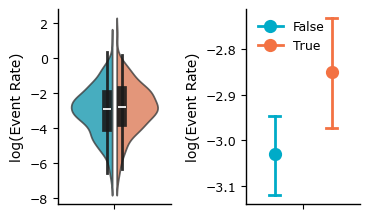

In [31]:
#plt.setp(ax, ylim=[-8,2])

fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(3.8,2.3))
sb.violinplot(data=df2,ax=ax[0],y='log_rate',hue='is_engram',palette=palette,inner='box',
              gap=0.1,density_norm='width',split=True,alpha=0.8,legend=False,
              inner_kws=dict(box_width=7, whis_width=2, color="0.1",alpha=0.9))
#ax[0].set_ylim(-.1,1)
sb.pointplot(data=df2,y='log_rate',hue='is_engram',palette=palette,ax=ax[1],dodge=.5,
            errorbar='ci', capsize=.1,markersize=8,linewidth=2)
plt.legend(frameon=False)
sb.despine()
for a in ax.flatten():
    a.set_ylabel('log(Event Rate)')
plt.tight_layout()
plt.savefig('SuppFig8C_recall1_rates_baselinerest_lograte.svg',transparent=True)

In [32]:
df2['animal_cell'] = df2['animal'] + "_" + df2['cell']

model = sm.MixedLM.from_formula(
    "log_rate ~ C(is_engram)",
    data=df2,
    groups=df2["animal"],  # Cell is nested within animal
).fit()
model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:                MixedLM   Dependent Variable:   log_rate  
No. Observations:     1464      Method:               REML      
No. Groups:           9         Scale:                1.5464    
Min. group size:      116       Log-Likelihood:       -2414.4955
Max. group size:      191       Converged:            Yes       
Mean group size:      162.7                                     
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -3.052    0.209 -14.582 0.000 -3.462 -2.642
C(is_engram)[T.True]  0.201    0.069   2.916 0.004  0.066  0.336
Group Var             0.379    0.157                            
================================================================

"""